In [2]:
import os
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

In [3]:
def orthogonalize_attributes(C):
    Q, _ = np.linalg.qr(C)
    return Q

def load_ml100k(path):
    ratings_cols = ['user_id', 'item_id', 'rating', 'timestamp']
    ratings = pd.read_csv(os.path.join(path, 'u.data'), sep='\t', names=ratings_cols, encoding='latin-1')
    item_cols = ['movie_id', 'movie_title', 'release_date', 'video_release_date', 'IMDb_URL', 'unknown', 'Action', 'Adventure', 'Animation', 'Childrens', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western']
    items = pd.read_csv(os.path.join(path, 'u.item'), sep='|', names=item_cols, encoding='latin-1')
    num_users = ratings['user_id'].nunique()
    num_items = items['movie_id'].nunique()
    R_matrix = np.zeros((num_users, num_items))
    for row in ratings.itertuples():
        R_matrix[row.user_id - 1, row.item_id - 1] = row.rating
    items['release_year'] = pd.to_datetime(items['release_date']).dt.year
    items['release_year'] = items['release_year'].fillna(items['release_year'].mode()[0])
    year_bins = pd.cut(items['release_year'], bins=np.arange(1900, 2025, 7), labels=False)
    year_onehot = pd.get_dummies(year_bins).values
    genre_cols = item_cols[5:]
    genres_onehot = items[genre_cols].values
    C = np.concatenate([year_onehot, genres_onehot], axis=1)
    V_A = orthogonalize_attributes(C)
    return R_matrix, V_A

def load_ml1m(path):
    ratings_cols = ['user_id', 'item_id', 'rating', 'timestamp']
    ratings = pd.read_csv(os.path.join(path, 'ratings.dat'), sep='::', names=ratings_cols, engine='python', encoding='latin-1')
    item_cols = ['movie_id', 'title', 'genres']
    items = pd.read_csv(os.path.join(path, 'movies.dat'), sep='::', names=item_cols, engine='python', encoding='latin-1')
    user_mapping = {id: idx for idx, id in enumerate(ratings['user_id'].unique())}
    item_mapping = {id: idx for idx, id in enumerate(items['movie_id'].unique())}
    num_users = len(user_mapping)
    num_items = len(item_mapping)
    R_matrix = np.zeros((num_users, num_items))
    for row in ratings.itertuples():
        if row.item_id in item_mapping:
            R_matrix[user_mapping[row.user_id], item_mapping[row.item_id]] = row.rating
    items['release_year'] = items['title'].str.extract(r'\((\d{4})\)').astype(float)
    items['release_year'] = items['release_year'].fillna(items['release_year'].mode()[0])
    year_bins = pd.cut(items['release_year'], bins=np.arange(1900, 2025, 7), labels=False)
    year_onehot = pd.get_dummies(year_bins).values
    all_genres = set()
    for genres in items['genres'].str.split('|'):
        all_genres.update(genres)
    all_genres = list(all_genres)
    genres_onehot = np.zeros((num_items, len(all_genres)))
    for idx, row in enumerate(items.itertuples()):
        movie_genres = row.genres.split('|')
        for j, g in enumerate(all_genres):
            if g in movie_genres:
                genres_onehot[idx, j] = 1
    C = np.concatenate([year_onehot, genres_onehot], axis=1)
    V_A = orthogonalize_attributes(C)
    return R_matrix, V_A, user_mapping, item_mapping

In [4]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

In [5]:
class SemiAutoencoder(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super(SemiAutoencoder, self).__init__()
        self.encoder = nn.Linear(input_dim, hidden_dim)
        self.decoder = nn.Linear(hidden_dim, input_dim)

    def forward(self, x):
        encoded = torch.sigmoid(self.encoder(x))
        decoded = torch.sigmoid(self.decoder(encoded))
        return encoded, decoded

class DMF(nn.Module):
    def __init__(self, num_users, num_items, latent_dim, hidden_layers):
        super(DMF, self).__init__()
        self.V = nn.Parameter(torch.randn(num_items, latent_dim))
        layers = []
        input_size = latent_dim
        for h in hidden_layers:
            layers.append(nn.Linear(input_size, h))
            layers.append(nn.Sigmoid())
            input_size = h
        layers.append(nn.Linear(input_size, num_users))
        layers.append(nn.Sigmoid())
        self.network = nn.Sequential(*layers)

    def forward(self):
        out = self.network(self.V)
        return out.T

class FSTDMF(nn.Module):
    def __init__(self, num_users, num_items, latent_dim, hidden_layers):
        super(FSTDMF, self).__init__()
        self.V = nn.Parameter(torch.randn(num_items, latent_dim))
        layers = []
        input_size = latent_dim
        for h in hidden_layers:
            layers.append(nn.Linear(input_size, h))
            layers.append(nn.Sigmoid())
            input_size = h
        layers.append(nn.Linear(input_size, num_users))
        layers.append(nn.Sigmoid())
        self.network = nn.Sequential(*layers)

    def forward(self):
        out = self.network(self.V)
        return out.T

In [6]:
def pretrain_semi_autoencoder(R_matrix, hidden_dim, epochs, lr):
    _, num_users = R_matrix.shape[1], R_matrix.shape[0]
    input_dim = num_users
    sa = SemiAutoencoder(input_dim, hidden_dim)
    optimizer = optim.Adam(sa.parameters(), lr=lr)
    R_tensor = torch.FloatTensor(R_matrix).T 
    mask = (R_tensor > 0).float()
    R_tensor_norm = mask * ((R_tensor - 1.0) / 4.0)
    for _ in range(epochs):
        optimizer.zero_grad()
        encoded, decoded = sa(R_tensor_norm)
        loss = torch.sum(mask * (decoded - R_tensor_norm) ** 2) / torch.sum(mask)
        loss.backward()
        optimizer.step()
    return sa, encoded.detach()

In [7]:
def fstdmf_loss_function(predicted_R, target_R_norm, mask, model, V_A_tensor, alpha, beta, eta):
    num_observed = torch.sum(mask)
    mse_loss = torch.sum(mask * (predicted_R - target_R_norm) ** 2) / num_observed
    l2_reg_W = 0.0
    for name, param in model.network.named_parameters():
        if 'weight' in name:
            l2_reg_W += torch.sum(param ** 2)
    l2_reg_W = (beta / 2.0) * (l2_reg_W / num_observed)
    l2_reg_V = (alpha / 2.0) * (torch.sum(model.V ** 2) / num_observed)
    projection = torch.matmul(V_A_tensor.T, model.V)
    subspace_loss = (alpha * eta / 2.0) * (torch.sum(projection ** 2) / num_observed)
    total_loss = mse_loss + l2_reg_V + l2_reg_W - subspace_loss
    return total_loss

def train_fstdmf(R_matrix, V_A, V_init, hidden_layers, epochs, lr, alpha, beta, eta):
    num_users, num_items = R_matrix.shape
    latent_dim = V_init.shape[1] if V_init is not None else V_A.shape[1]
    model = FSTDMF(num_users, num_items, latent_dim, hidden_layers)
    if V_init is not None:
        model.V.data = V_init.clone()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    R_tensor = torch.FloatTensor(R_matrix)
    mask = (R_tensor > 0).float()
    R_tensor_norm = mask * ((R_tensor - 1.0) / 4.0)
    V_A_tensor = torch.FloatTensor(V_A)
    for _ in range(epochs):
        model.train()
        optimizer.zero_grad()
        predictions = model()
        loss = fstdmf_loss_function(predictions, R_tensor_norm, mask, model, V_A_tensor, alpha, beta, eta)
        loss.backward()
        optimizer.step()
    model.eval()
    return model

def train_dmf(R_matrix, V_init, hidden_layers, epochs, lr, alpha, beta):
    num_users, num_items = R_matrix.shape
    latent_dim = V_init.shape[1] if V_init is not None else hidden_layers[0]
    model = DMF(num_users, num_items, latent_dim, hidden_layers)
    if V_init is not None:
        model.V.data = V_init.clone()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    R_tensor = torch.FloatTensor(R_matrix)
    mask = (R_tensor > 0).float()
    R_tensor_norm = mask * ((R_tensor - 1.0) / 4.0)
    for _ in range(epochs):
        model.train()
        optimizer.zero_grad()
        predictions = model()
        num_observed = torch.sum(mask)
        mse_loss = torch.sum(mask * (predictions - R_tensor_norm) ** 2) / num_observed
        reg_V = (alpha / 2.0) * (torch.sum(model.V ** 2) / num_observed)
        reg_W = 0.0
        for name, param in model.network.named_parameters():
            if 'weight' in name:
                reg_W += torch.sum(param ** 2)
        reg_W = (beta / 2.0) * (reg_W / num_observed)
        total_loss = mse_loss + reg_V + reg_W
        total_loss.backward()
        optimizer.step()
    model.eval()
    return model

In [8]:
def create_train_test_split(R_matrix, train_ratio):
    R_train = np.zeros_like(R_matrix)
    test_indices = []
    observed_indices = np.argwhere(R_matrix > 0)
    np.random.shuffle(observed_indices)
    train_size = int(len(observed_indices) * train_ratio)
    train_indices = observed_indices[:train_size]
    test_indices_arr = observed_indices[train_size:]
    for u, i in train_indices:
        R_train[u, i] = R_matrix[u, i]
    for u, i in test_indices_arr:
        test_indices.append((u, i))
    return R_train, test_indices

def evaluate_model(model, R_matrix, test_indices):
    model.eval()
    with torch.no_grad():
        predictions = model().numpy()
    predictions = (predictions * 4.0) + 1.0
    mae_sum = 0
    rmse_sum = 0
    count = len(test_indices)
    for u, i in test_indices:
        true_rating = R_matrix[u, i]
        pred_rating = predictions[u, i]
        mae_sum += np.abs(true_rating - pred_rating)
        rmse_sum += (true_rating - pred_rating) ** 2
    mae = mae_sum / count
    rmse = np.sqrt(rmse_sum / count)
    return mae, rmse

In [9]:
def run_movielens100k_experiment(data_path):
    set_seed(42)
    R_matrix, V_A = load_ml100k(data_path)
    train_ratios = [0.7, 0.5, 0.3]
    metrics = {'DMF': {}, 'FSTDMF': {}}
    latent_dim = 100
    hidden_layers = [100]
    epochs = 50
    lr = 0.0123
    eta = 1.0
    reg_coeffs = [0.10, 0.15] 
    for ratio in train_ratios:
        R_train, test_indices = create_train_test_split(R_matrix, ratio)
        best_dmf_mae, best_dmf_rmse, best_dmf_reg = float('inf'), float('inf'), None
        for reg in reg_coeffs:
            set_seed(42)
            V_init_dmf = torch.randn(R_matrix.shape[1], latent_dim) * 0.1
            dmf_model = train_dmf(R_train, V_init=V_init_dmf, hidden_layers=hidden_layers, 
                epochs=epochs, lr=lr, alpha=reg, beta=reg)
            mae, rmse = evaluate_model(dmf_model, R_matrix, test_indices)
            if mae < best_dmf_mae:
                best_dmf_mae, best_dmf_rmse, best_dmf_reg = mae, rmse, reg
        metrics['DMF'][ratio] = {'MAE': best_dmf_mae, 'RMSE': best_dmf_rmse}
        best_fst_mae, best_fst_rmse, best_fst_reg = float('inf'), float('inf'), None
        for reg in reg_coeffs:
            set_seed(42)
            _, V_init_sa = pretrain_semi_autoencoder(R_train, hidden_dim=latent_dim, epochs=epochs, lr=lr)
            fstdmf_model = train_fstdmf(R_train, V_A, V_init=V_init_sa, hidden_layers=hidden_layers, 
                epochs=epochs, lr=lr, alpha=reg, beta=reg, eta=eta)
            mae, rmse = evaluate_model(fstdmf_model, R_matrix, test_indices)
            if mae < best_fst_mae:
                best_fst_mae, best_fst_rmse, best_fst_reg = mae, rmse, reg
        metrics['FSTDMF'][ratio] = {'MAE': best_fst_mae, 'RMSE': best_fst_rmse}
        print(f"ML-100K | Train Ratio: {ratio} | Best DMF (Reg: {best_dmf_reg}, MAE: {best_dmf_mae:.3f}, RMSE: {best_dmf_rmse:.3f}) | Best FSTDMF (Reg: {best_fst_reg}, MAE: {best_fst_mae:.3f}, RMSE: {best_fst_rmse:.3f})")
    return metrics

In [10]:
def run_movielens1m_experiment(data_path):
    set_seed(42)
    R_matrix, V_A, _, _ = load_ml1m(data_path)
    train_ratios = [0.7, 0.5, 0.3]
    metrics = {'DMF': {}, 'FSTDMF': {}}
    latent_dim = 100
    hidden_layers = [100]
    epochs, lr, eta = 50, 0.0123, 1.0
    reg_coeffs = [0.10, 0.15]
    for ratio in train_ratios:
        R_train, test_indices = create_train_test_split(R_matrix, ratio)
        best_dmf_mae, best_dmf_rmse, best_dmf_reg = float('inf'), float('inf'), None
        for reg in reg_coeffs:
            set_seed(42)
            V_init_dmf = torch.randn(R_matrix.shape[1], latent_dim) * 0.1
            dmf_model = train_dmf(R_train, V_init=V_init_dmf, hidden_layers=hidden_layers, 
                epochs=epochs, lr=lr, alpha=reg, beta=reg)
            mae, rmse = evaluate_model(dmf_model, R_matrix, test_indices)
            if mae < best_dmf_mae:
                best_dmf_mae, best_dmf_rmse, best_dmf_reg = mae, rmse, reg
        metrics['DMF'][ratio] = {'MAE': best_dmf_mae, 'RMSE': best_dmf_rmse}
        best_fst_mae, best_fst_rmse, best_fst_reg = float('inf'), float('inf'), None
        for reg in reg_coeffs:
            set_seed(42)
            _, V_init_sa = pretrain_semi_autoencoder(R_train, hidden_dim=latent_dim, epochs=epochs, lr=lr)
            fstdmf_model = train_fstdmf(R_train, V_A, V_init=V_init_sa, hidden_layers=hidden_layers, 
                epochs=epochs, lr=lr, alpha=reg, beta=reg, eta=eta)
            mae, rmse = evaluate_model(fstdmf_model, R_matrix, test_indices)
            if mae < best_fst_mae:
                best_fst_mae, best_fst_rmse, best_fst_reg = mae, rmse, reg
        metrics['FSTDMF'][ratio] = {'MAE': best_fst_mae, 'RMSE': best_fst_rmse}
        print(f"ML-1M   | Train Ratio: {ratio} | Best DMF (Reg: {best_dmf_reg}, MAE: {best_dmf_mae:.3f}, RMSE: {best_dmf_rmse:.3f}) | Best FSTDMF (Reg: {best_fst_reg}, MAE: {best_fst_mae:.3f}, RMSE: {best_fst_rmse:.3f})")
    return metrics

In [11]:
def run_dimension_sensitivity_analysis(data_path):
    set_seed(42)
    R_matrix, V_A, _, _ = load_ml1m(data_path)
    train_ratios = [0.7, 0.5, 0.3]
    dimensions = [100, 300, 500]
    metrics = {'DMF': {d: {} for d in dimensions}, 'FSTDMF': {d: {} for d in dimensions}}
    epochs, lr, eta = 50, 0.0123, 1.0
    reg_coeffs = [0.10, 0.15]
    for ratio in train_ratios:
        R_train, test_indices = create_train_test_split(R_matrix, ratio)
        print(f"\n--- Dimension Sensitivity | Train Ratio: {ratio} ---")
        for dim in dimensions:
            hidden_layers = [dim]
            best_dmf_mae, best_dmf_rmse, best_dmf_reg = float('inf'), float('inf'), None
            for reg in reg_coeffs:
                set_seed(42)
                V_init_dmf = torch.randn(R_matrix.shape[1], dim) * 0.1
                dmf_model = train_dmf(R_train, V_init=V_init_dmf, hidden_layers=hidden_layers,
                    epochs=epochs, lr=lr, alpha=reg, beta=reg)
                mae, rmse = evaluate_model(dmf_model, R_matrix, test_indices)
                if mae < best_dmf_mae:
                    best_dmf_mae, best_dmf_rmse, best_dmf_reg = mae, rmse, reg
            metrics['DMF'][dim][ratio] = {'MAE': best_dmf_mae, 'RMSE': best_dmf_rmse}
            print(f"DMF    | Dim: {dim:3d} | Reg: {best_dmf_reg} | MAE: {best_dmf_mae:.3f} | RMSE: {best_dmf_rmse:.3f}")
            best_fst_mae, best_fst_rmse, best_fst_reg = float('inf'), float('inf'), None
            for reg in reg_coeffs:
                set_seed(42)
                _, V_init_sa = pretrain_semi_autoencoder(R_train, hidden_dim=dim, epochs=epochs, lr=lr)
                fstdmf_model = train_fstdmf(R_train, V_A, V_init=V_init_sa, hidden_layers=hidden_layers,
                    epochs=epochs, lr=lr, alpha=reg, beta=reg, eta=eta)
                mae, rmse = evaluate_model(fstdmf_model, R_matrix, test_indices)
                if mae < best_fst_mae:
                    best_fst_mae, best_fst_rmse, best_fst_reg = mae, rmse, reg
            metrics['FSTDMF'][dim][ratio] = {'MAE': best_fst_mae, 'RMSE': best_fst_rmse}
            print(f"FSTDMF | Dim: {dim:3d} | Reg: {best_fst_reg} | MAE: {best_fst_mae:.3f} | RMSE: {best_fst_rmse:.3f}")
    return metrics

In [12]:
def run_ablation_study(data_path):
    set_seed(42)
    R_matrix, V_A = load_ml100k(data_path)
    train_ratios = [0.7, 0.5, 0.3]
    latent_dim, hidden_layers = 100, [100]
    epochs, lr = 50, 0.0123
    reg_coeffs = [0.10, 0.15]
    metrics = {'DMF': {}, 'DMF(+SA)': {}, 'DMF(+FST)': {}, 'FSTDMF': {}}
    for ratio in train_ratios:
        print(f"\n--- Ablation Study for Train Ratio: {ratio} ---")
        R_train, test_indices = create_train_test_split(R_matrix, ratio)
        best_mae, best_rmse, best_reg = float('inf'), float('inf'), None
        for reg in reg_coeffs:
            set_seed(42)
            V_init_random = torch.randn(R_matrix.shape[1], latent_dim) * 0.1
            dmf_model = train_dmf(R_train, V_init=V_init_random, hidden_layers=hidden_layers, epochs=epochs, lr=lr, alpha=reg, beta=reg)
            mae, rmse = evaluate_model(dmf_model, R_matrix, test_indices)
            if mae < best_mae:
                best_mae, best_rmse, best_reg = mae, rmse, reg
        metrics['DMF'][ratio] = (best_mae, best_rmse)
        print(f"DMF       | Reg: {best_reg} | MAE: {best_mae:.3f} | RMSE: {best_rmse:.3f}")
        best_mae, best_rmse, best_reg = float('inf'), float('inf'), None
        for reg in reg_coeffs:
            set_seed(42)
            _, V_init_sa = pretrain_semi_autoencoder(R_train, hidden_dim=latent_dim, epochs=epochs, lr=lr)
            dmf_sa_model = train_dmf(R_train, V_init=V_init_sa, hidden_layers=hidden_layers, epochs=epochs, lr=lr, alpha=reg, beta=reg)
            mae, rmse = evaluate_model(dmf_sa_model, R_matrix, test_indices)
            if mae < best_mae:
                best_mae, best_rmse, best_reg = mae, rmse, reg
        metrics['DMF(+SA)'][ratio] = (best_mae, best_rmse)
        print(f"DMF(+SA)  | Reg: {best_reg} | MAE: {best_mae:.3f} | RMSE: {best_rmse:.3f}")
        best_mae, best_rmse, best_reg = float('inf'), float('inf'), None
        for reg in reg_coeffs:
            set_seed(42)
            V_init_random = torch.randn(R_matrix.shape[1], latent_dim) * 0.1
            dmf_fst_model = train_fstdmf(R_train, V_A, V_init=V_init_random, hidden_layers=hidden_layers, epochs=epochs, lr=lr, alpha=reg, beta=reg, eta=1.0)
            mae, rmse = evaluate_model(dmf_fst_model, R_matrix, test_indices)
            if mae < best_mae:
                best_mae, best_rmse, best_reg = mae, rmse, reg
        metrics['DMF(+FST)'][ratio] = (best_mae, best_rmse)
        print(f"DMF(+FST) | Reg: {best_reg} | MAE: {best_mae:.3f} | RMSE: {best_rmse:.3f}")
        best_mae, best_rmse, best_reg = float('inf'), float('inf'), None
        for reg in reg_coeffs:
            set_seed(42)
            _, V_init_sa = pretrain_semi_autoencoder(R_train, hidden_dim=latent_dim, epochs=epochs, lr=lr)
            fstdmf_model = train_fstdmf(R_train, V_A, V_init=V_init_sa, hidden_layers=hidden_layers, epochs=epochs, lr=lr, alpha=reg, beta=reg, eta=1.0)
            mae, rmse = evaluate_model(fstdmf_model, R_matrix, test_indices)
            if mae < best_mae:
                best_mae, best_rmse, best_reg = mae, rmse, reg
        metrics['FSTDMF'][ratio] = (best_mae, best_rmse)
        print(f"FSTDMF    | Reg: {best_reg} | MAE: {best_mae:.3f} | RMSE: {best_rmse:.3f}")
    return metrics

In [13]:
def run_layer_sensitivity_analysis(data_path):
    set_seed(42)
    R_matrix, V_A = load_ml100k(data_path)
    train_ratios = [0.7, 0.5, 0.3]
    layer_configs = {'1-layer': [100], '2-layer': [100, 100], '3-layer': [100, 100, 100]}
    metrics = {'FSTDMF': {name: {} for name in layer_configs}}
    epochs, lr, eta, latent_dim = 50, 0.0123, 1.0, 100
    reg_coeffs = [0.10, 0.15]
    for ratio in train_ratios:
        R_train, test_indices = create_train_test_split(R_matrix, ratio)
        print(f"\n--- Layer Sensitivity | Train Ratio: {ratio} ---")
        for layers_name, hidden_layers in layer_configs.items():
            best_mae, best_rmse, best_reg = float('inf'), float('inf'), None
            for reg in reg_coeffs:
                set_seed(42)
                _, V_init_sa = pretrain_semi_autoencoder(R_train, hidden_dim=latent_dim, epochs=epochs, lr=lr)
                fstdmf_model = train_fstdmf(R_train, V_A, V_init=V_init_sa, hidden_layers=hidden_layers,
                    epochs=epochs, lr=lr, alpha=reg, beta=reg, eta=eta)
                mae, rmse = evaluate_model(fstdmf_model, R_matrix, test_indices)
                if mae < best_mae:
                    best_mae, best_rmse, best_reg = mae, rmse, reg
            metrics['FSTDMF'][layers_name][ratio] = {'MAE': best_mae, 'RMSE': best_rmse}
            print(f"{layers_name} | Reg: {best_reg} | Best MAE: {best_mae:.3f} | Best RMSE: {best_rmse:.3f}")
    return metrics

In [14]:
dataset_100k_path = "../ml-100k"
dataset_1m_path = "../ml-1m"

print("--- Evaluating Model on MovieLens-100k Dataset ---")
metrics_100k = run_movielens100k_experiment(dataset_100k_path)

print("\n--- Evaluating Model on MovieLens-1M Dataset ---")
metrics_1m = run_movielens1m_experiment(dataset_1m_path)

print("\n--- Latent Feature Dimension Sensitivity Analysis (ML-1M) ---")
metrics_dim = run_dimension_sensitivity_analysis(dataset_1m_path)

print("\n--- Number of Layers Sensitivity Analysis (ML-100K) ---")
metrics_layers = run_layer_sensitivity_analysis(dataset_100k_path)

print("\n--- Ablation Study (ML-100K) ---")
metrics_ablation = run_ablation_study(dataset_100k_path)

--- Evaluating Model on MovieLens-100k Dataset ---
ML-100K | Train Ratio: 0.7 | Best DMF (Reg: 0.15, MAE: 0.738, RMSE: 0.943) | Best FSTDMF (Reg: 0.1, MAE: 0.719, RMSE: 0.923)
ML-100K | Train Ratio: 0.5 | Best DMF (Reg: 0.15, MAE: 0.754, RMSE: 0.962) | Best FSTDMF (Reg: 0.15, MAE: 0.731, RMSE: 0.933)
ML-100K | Train Ratio: 0.3 | Best DMF (Reg: 0.15, MAE: 0.781, RMSE: 0.997) | Best FSTDMF (Reg: 0.15, MAE: 0.754, RMSE: 0.961)

--- Evaluating Model on MovieLens-1M Dataset ---
ML-1M   | Train Ratio: 0.7 | Best DMF (Reg: 0.1, MAE: 0.717, RMSE: 0.913) | Best FSTDMF (Reg: 0.1, MAE: 0.703, RMSE: 0.894)
ML-1M   | Train Ratio: 0.5 | Best DMF (Reg: 0.1, MAE: 0.719, RMSE: 0.916) | Best FSTDMF (Reg: 0.1, MAE: 0.706, RMSE: 0.899)
ML-1M   | Train Ratio: 0.3 | Best DMF (Reg: 0.15, MAE: 0.728, RMSE: 0.928) | Best FSTDMF (Reg: 0.1, MAE: 0.716, RMSE: 0.914)

--- Latent Feature Dimension Sensitivity Analysis (ML-1M) ---

--- Dimension Sensitivity | Train Ratio: 0.7 ---
DMF    | Dim: 100 | Reg: 0.1 | MAE: 

In [15]:
paper_table3 = {
    'DMF':    {0.7: (0.729, 0.926), 0.5: (0.744, 0.944), 0.3: (0.767, 0.972)},
    'FSTDMF': {0.7: (0.701, 0.893), 0.5: (0.713, 0.909), 0.3: (0.744, 0.945)},
}
paper_table4 = {
    'DMF':    {0.7: (0.693, 0.854), 0.5: (0.700, 0.871), 0.3: (0.720, 0.914)},
    'FSTDMF': {0.7: (0.667, 0.850), 0.5: (0.678, 0.863), 0.3: (0.696, 0.885)},
}

def compare_with_paper(obtained, paper, dataset_name):
    print(f"\n=== {dataset_name}: obtained vs. paper (Δ%) ===")
    for model_name in ['DMF', 'FSTDMF']:
        for ratio in [0.7, 0.5, 0.3]:
            mae_o, rmse_o = obtained[model_name][ratio]['MAE'], obtained[model_name][ratio]['RMSE']
            mae_p, rmse_p = paper[model_name][ratio]
            d_mae = 100 * (mae_o - mae_p) / mae_p
            d_rmse = 100 * (rmse_o - rmse_p) / rmse_p
            print(f"{model_name:8s} | ratio={ratio} | "
                  f"MAE: {mae_o:.3f} vs {mae_p:.3f} (Δ{d_mae:+.1f}%) | "
                  f"RMSE: {rmse_o:.3f} vs {rmse_p:.3f} (Δ{d_rmse:+.1f}%)")

compare_with_paper(metrics_100k, paper_table3, "MovieLens-100K (Table 3)")
compare_with_paper(metrics_1m, paper_table4, "MovieLens-1M (Table 4)")


=== MovieLens-100K (Table 3): obtained vs. paper (Δ%) ===
DMF      | ratio=0.7 | MAE: 0.738 vs 0.729 (Δ+1.2%) | RMSE: 0.943 vs 0.926 (Δ+1.8%)
DMF      | ratio=0.5 | MAE: 0.754 vs 0.744 (Δ+1.3%) | RMSE: 0.962 vs 0.944 (Δ+1.9%)
DMF      | ratio=0.3 | MAE: 0.781 vs 0.767 (Δ+1.8%) | RMSE: 0.997 vs 0.972 (Δ+2.5%)
FSTDMF   | ratio=0.7 | MAE: 0.719 vs 0.701 (Δ+2.6%) | RMSE: 0.923 vs 0.893 (Δ+3.3%)
FSTDMF   | ratio=0.5 | MAE: 0.731 vs 0.713 (Δ+2.5%) | RMSE: 0.933 vs 0.909 (Δ+2.6%)
FSTDMF   | ratio=0.3 | MAE: 0.754 vs 0.744 (Δ+1.3%) | RMSE: 0.961 vs 0.945 (Δ+1.7%)

=== MovieLens-1M (Table 4): obtained vs. paper (Δ%) ===
DMF      | ratio=0.7 | MAE: 0.717 vs 0.693 (Δ+3.4%) | RMSE: 0.913 vs 0.854 (Δ+6.9%)
DMF      | ratio=0.5 | MAE: 0.719 vs 0.700 (Δ+2.7%) | RMSE: 0.916 vs 0.871 (Δ+5.2%)
DMF      | ratio=0.3 | MAE: 0.728 vs 0.720 (Δ+1.1%) | RMSE: 0.928 vs 0.914 (Δ+1.5%)
FSTDMF   | ratio=0.7 | MAE: 0.703 vs 0.667 (Δ+5.4%) | RMSE: 0.894 vs 0.850 (Δ+5.1%)
FSTDMF   | ratio=0.5 | MAE: 0.706 vs 0.678 (

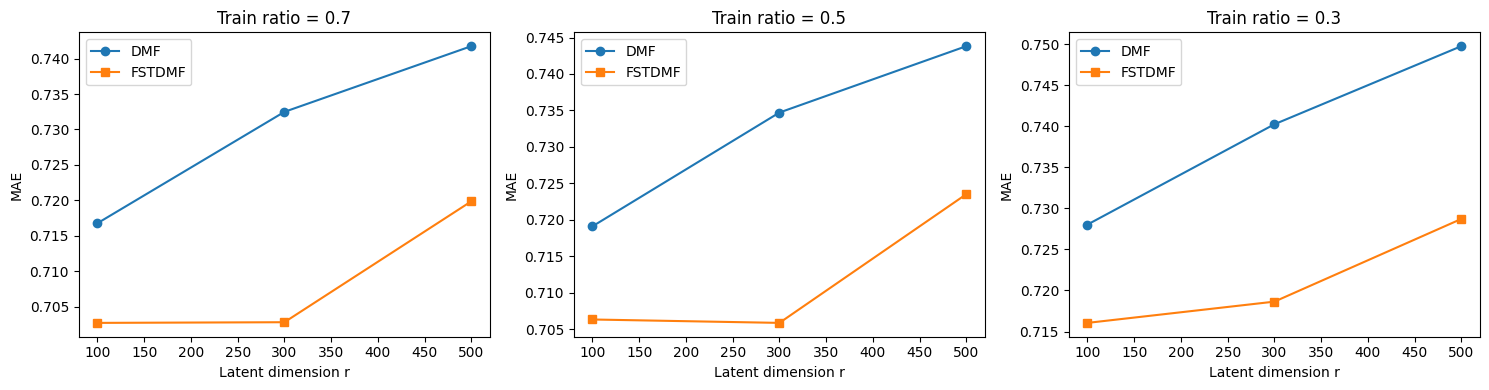

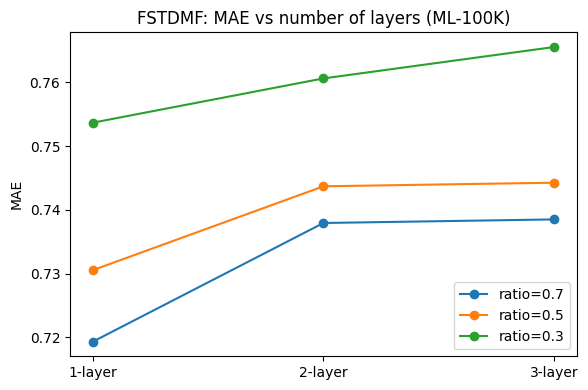

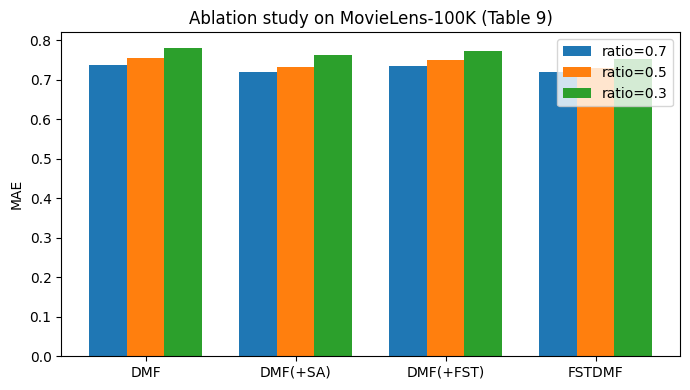

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
dimensions = [100, 300, 500]
for ax, ratio in zip(axes, [0.7, 0.5, 0.3]):
    dmf_mae = [metrics_dim['DMF'][d][ratio]['MAE'] for d in dimensions]
    fst_mae = [metrics_dim['FSTDMF'][d][ratio]['MAE'] for d in dimensions]
    ax.plot(dimensions, dmf_mae, marker='o', label='DMF')
    ax.plot(dimensions, fst_mae, marker='s', label='FSTDMF')
    ax.set_title(f'Train ratio = {ratio}')
    ax.set_xlabel('Latent dimension r')
    ax.set_ylabel('MAE')
    ax.legend()
plt.tight_layout()
plt.savefig('fig6_reproduction.png', dpi=150)
plt.show()
fig, ax = plt.subplots(figsize=(6, 4))
for ratio in [0.7, 0.5, 0.3]:
    maes = [metrics_layers['FSTDMF'][name][ratio]['MAE'] for name in ['1-layer', '2-layer', '3-layer']]
    ax.plot(['1-layer', '2-layer', '3-layer'], maes, marker='o', label=f'ratio={ratio}')
ax.set_ylabel('MAE')
ax.set_title('FSTDMF: MAE vs number of layers (ML-100K)')
ax.legend()
plt.tight_layout()
plt.savefig('table8_reproduction.png', dpi=150)
plt.show()
fig, ax = plt.subplots(figsize=(7, 4))
model_names = ['DMF', 'DMF(+SA)', 'DMF(+FST)', 'FSTDMF']
x = np.arange(len(model_names))
width = 0.25
for i, ratio in enumerate([0.7, 0.5, 0.3]):
    maes = [metrics_ablation[m][ratio][0] for m in model_names]
    ax.bar(x + i * width, maes, width, label=f'ratio={ratio}')
ax.set_xticks(x + width)
ax.set_xticklabels(model_names)
ax.set_ylabel('MAE')
ax.set_title('Ablation study on MovieLens-100K (Table 9)')
ax.legend()
plt.tight_layout()
plt.savefig('table9_reproduction.png', dpi=150)
plt.show()